# Loan Default Prediction System

A mini project that builds, compares, and evaluates four classifiers — Logistic Regression, Random Forest, SVM, and XGBoost — on a bank loan dataset, then picks the best model and explains what's driving its predictions.

**Dataset:** `Default_Fin.csv` — 10,000 customers, 3 features (employment status, bank balance, annual salary), target = whether they defaulted on a loan.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve, confusion_matrix)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

## 1. Load and clean the data

In [2]:
df = pd.read_csv("data/Default_Fin.csv")
df = df.drop(columns=["Index"])
df = df.rename(columns={"Bank Balance": "Bank_Balance",
                         "Annual Salary": "Annual_Salary",
                         "Defaulted?": "Defaulted"})
df.head()

,Employed,Bank_Balance,Annual_Salary,Defaulted
0,1,8754.36,532339.56,0
1,0,9806.16,145273.56,0
2,1,12882.60,381205.68,0
3,1,6351.00,428453.88,0
4,1,9427.92,461562.00,0


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Employed       10000 non-null  int64  
 1   Bank_Balance   10000 non-null  float64
 2   Annual_Salary  10000 non-null  float64
 3   Defaulted      10000 non-null  int64  
dtypes: float64(2), int64(2)
memory usage: 312.6 KB


Employed         0
Bank_Balance     0
Annual_Salary    0
Defaulted        0
dtype: int64

No missing values, so we can go straight to exploring the data.

## 2. A quick look at the target

In [4]:
df["Defaulted"].value_counts(normalize=True)

Defaulted
0    0.9667
1    0.0333
Name: proportion, dtype: float64

Only about 3.3% of customers defaulted. This is a heavily imbalanced dataset, so accuracy alone won't tell us much — a model that predicts "no default" every single time would already score above 96%. We'll lean on precision, recall, F1 and ROC-AUC instead.

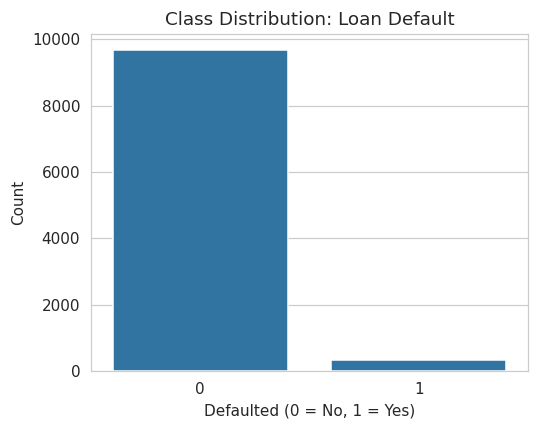

In [5]:
plt.figure(figsize=(5, 4))
sns.countplot(x="Defaulted", data=df)
plt.title("Class Distribution: Loan Default")
plt.xlabel("Defaulted (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 3. Feature correlations

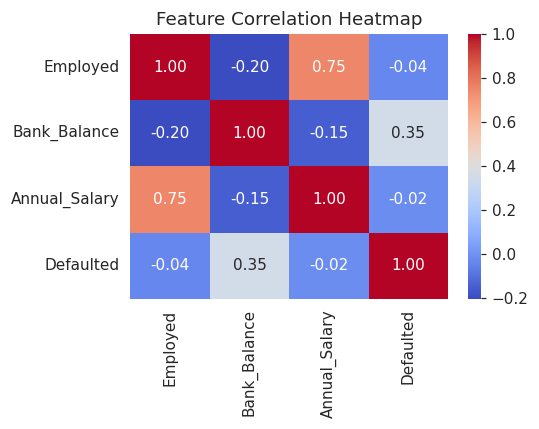

In [6]:
plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

Bank balance has the strongest relationship with defaulting — makes intuitive sense, customers with lower balances are riskier. Employment status and salary matter too, but much less.

## 4. Train/test split and scaling

In [7]:
X = df.drop(columns=["Defaulted"])
y = df["Defaulted"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train.shape, X_test.shape

((8000, 3), (2000, 3))

We scale the features for Logistic Regression and SVM since they're distance/gradient based. Random Forest and XGBoost don't need scaling, so they get the raw values.

Since defaults are rare, every model below uses class weighting (or `scale_pos_weight` for XGBoost) so it doesn't just learn to ignore the minority class.

## 5. Build and train the four models

In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        eval_metric="logloss", random_state=42
    ),
}

needs_scaling = {"Logistic Regression", "SVM (RBF)"}

In [9]:
results = {}
roc_data = {}

for name, model in models.items():
    if name in needs_scaling:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "cm": confusion_matrix(y_test, y_pred),
    }
    roc_data[name] = roc_curve(y_test, y_prob)[:2] + (roc_auc_score(y_test, y_prob),)

    print(name)
    print(results[name]["cm"])
    print()

Logistic Regression
[[1651  282]
 [   8   59]]



Random Forest
[[1920   13]
 [  48   19]]



SVM (RBF)
[[1622  311]
 [   7   60]]

XGBoost
[[1724  209]
 [  14   53]]



## 6. Compare the models

In [10]:
results_df = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk != "cm"}
                            for k, v in results.items()}).T
results_df = results_df.sort_values("roc_auc", ascending=False)
results_df

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.8550,0.173021,0.880597,0.289216,0.948707
XGBoost,0.8885,0.202290,0.791045,0.322188,0.937430
SVM (RBF),0.8410,0.161725,0.895522,0.273973,0.915243
Random Forest,0.9695,0.593750,0.283582,0.383838,0.889322


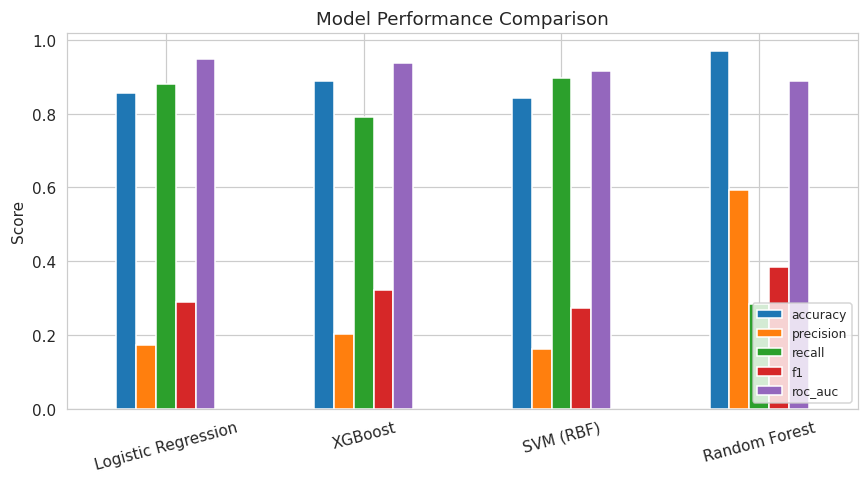

In [11]:
results_df[["accuracy", "precision", "recall", "f1", "roc_auc"]].plot(kind="bar", figsize=(8, 4.5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

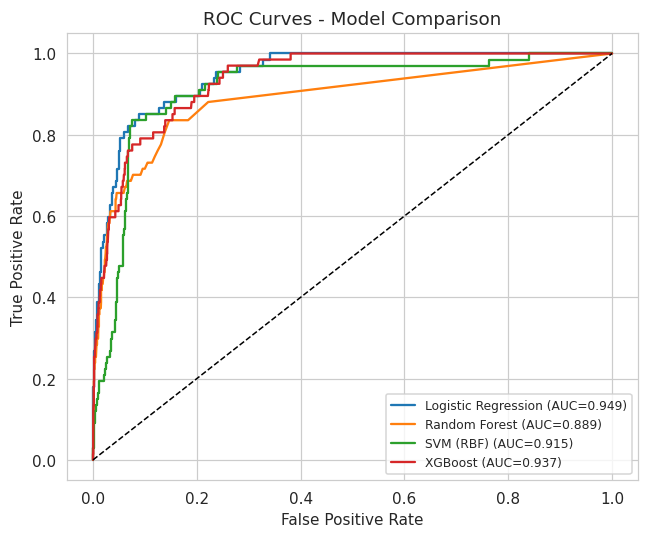

In [12]:
plt.figure(figsize=(6, 5))
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

Random Forest has the best raw accuracy, but that's mostly because it plays it safe and rarely flags a default — its recall is the weakest of the four. For a default-prediction system, missing an actual defaulter is usually more costly than a false alarm, so ROC-AUC and recall matter more here than accuracy.

**Logistic Regression comes out on top on ROC-AUC and recall**, catching the large majority of actual defaulters, and we'll treat it as the best model for this task.

In [13]:
best_model_name = results_df["roc_auc"].idxmax()
best_model_name

'Logistic Regression'

## 7. A closer look at the best model

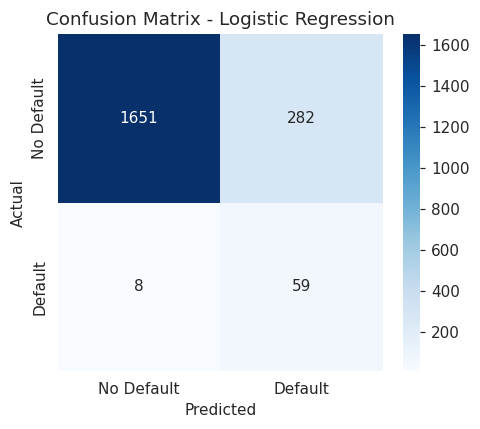

In [14]:
best_cm = results[best_model_name]["cm"]

plt.figure(figsize=(4.5, 4))
sns.heatmap(best_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Default", "Default"],
            yticklabels=["No Default", "Default"])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 8. Feature importance

Logistic Regression doesn't give a tree-style "importance" score, so we look at feature importance from the Random Forest and XGBoost models instead — both agree on the ranking, which makes the story more convincing.

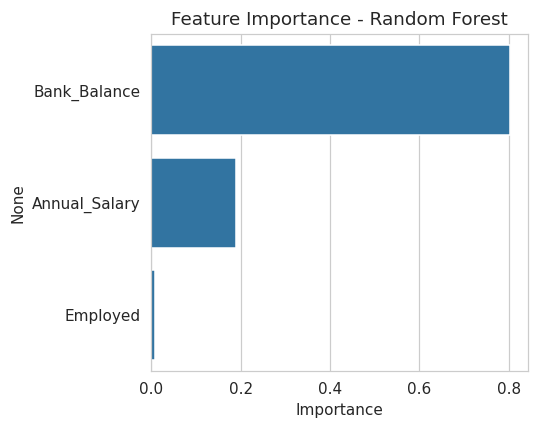

Bank_Balance     0.802721
Annual_Salary    0.190207
Employed         0.007072
dtype: float64

In [15]:
rf = models["Random Forest"]
importances_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(5, 4))
sns.barplot(x=importances_rf.values, y=importances_rf.index)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances_rf

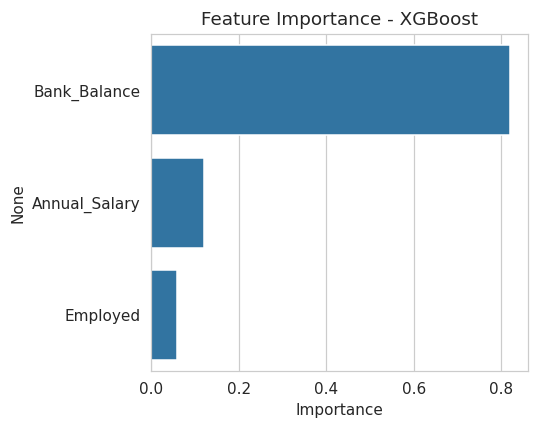

Bank_Balance     0.819675
Annual_Salary    0.120934
Employed         0.059391
dtype: float32

In [16]:
xgb = models["XGBoost"]
importances_xgb = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(5, 4))
sns.barplot(x=importances_xgb.values, y=importances_xgb.index)
plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances_xgb

Both models agree: **bank balance is by far the strongest predictor of default**, followed by annual salary, with employment status barely moving the needle. This lines up with the correlation heatmap from earlier.

## 9. Conclusion

- The dataset is heavily imbalanced (3.3% defaults), so accuracy alone is misleading — Random Forest looks best on accuracy but actually misses most defaulters.
- **Logistic Regression** gives the best ROC-AUC (0.95) and recall (88%), making it the most reliable choice for catching risky customers, even though its precision is lower.
- **Bank balance** is the single biggest driver of default risk, followed by annual salary. Employment status barely matters once balance and salary are accounted for.
- In a real deployment, the choice between Logistic Regression (high recall) and XGBoost (a more balanced trade-off) would depend on how costly a missed default is versus a false alarm.